In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#So OneHotEncoder converts categories into numbers.categorical columns such as:fuel,Petrol,Diesel,CNG
#Machine learning models generally need numbers rather than text.So OneHotEncoder converts categories into numbers.
from sklearn.preprocessing import OneHotEncoder

# GridSearchCV- it will try different model settings → compare them → choose the best settings
# Randomized-It also searches for the best model settings.But instead of trying every possible combination, it randomly tries some combinations
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV


#r2_score to evaluate how well my regression model predicts the actual used-car prices. A higher R² score indicates better model performance.
from sklearn.metrics import mean_squared_error, r2_score

#Linear Regression tries to find a relationship between your car features and price.
#Ridge = Linear Regression + protection against overfitting.
#lasso it can effectively remove less useful features.
from sklearn.linear_model import LinearRegression, Ridge, Lasso

#A Decision Tree makes decisions using conditions.
from sklearn.tree import DecisionTreeRegressor

#Random Forest uses many Decision Trees together.
from sklearn.ensemble import RandomForestRegressor

#xgboost It builds trees one after another, where later trees try to improve the mistakes made by earlier trees.
from xgboost import XGBRegressor

#to save your trained machine learning model.
import joblib

#Python sometimes displays warning messages that aren't actual errors.
import warnings

warnings.filterwarnings(action="ignore")

In [2]:
import sys
print(sys.executable)

c:\Program Files\Python312\python.exe


In [6]:
car_df = pd.read_csv("cardekho_dataset.csv")
car_df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
car_df.drop(["model"], axis=1, inplace=True)

In [8]:
cleaned_car_df = car_df[(car_df["km_driven"] < 500000) & (car_df["vehicle_age"] <= 15)].copy()

In [9]:
cleaned_car_df["fuel_type"] = cleaned_car_df["fuel_type"].replace("Electric", "Hybrid")

In [10]:
cleaned_car_df.loc[cleaned_car_df["car_name"] == "Nissan Kicks", "seats"] = 5

In [11]:
cleaned_car_df["selling_price_in_lakhs"] = cleaned_car_df["selling_price"] / 100000
cleaned_car_df.drop(["selling_price"], axis=1, inplace=True)

In [12]:
cleaned_car_df["vehicle_age"] = cleaned_car_df["vehicle_age"].replace(0, 1)

In [13]:
cleaned_car_df["km_driven_per_year"] = round(cleaned_car_df["km_driven"] / cleaned_car_df["vehicle_age"], 0)
cleaned_car_df["power_to_engine_ratio"] = round(cleaned_car_df["max_power"] * 1000 / cleaned_car_df["engine"], 2)

In [14]:
log_cols = ["km_driven", "engine", "max_power", "km_driven_per_year", "selling_price_in_lakhs"]
for col in log_cols:
    cleaned_car_df[col] = np.log1p(cleaned_car_df[col]).round(4)

In [15]:
cleaned_car_df["seats"] = cleaned_car_df["seats"].astype(str)

In [16]:
cleaned_car_df.to_csv("clean_car_data.csv", index=False)
print("Saved:", cleaned_car_df.shape)
cleaned_car_df.head()

Saved: (15333, 15)


,Unnamed: 0,car_name,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs,km_driven_per_year,power_to_engine_ratio
0,0,Maruti Alto,Maruti,9,11.6953,Individual,Petrol,Manual,19.70,6.6809,3.8565,5,0.7885,9.4981,58.17
1,1,Hyundai Grand,Hyundai,5,9.9035,Individual,Petrol,Manual,18.90,7.0884,4.4188,5,1.8718,8.2943,68.50
2,2,Hyundai i20,Hyundai,11,11.0021,Individual,Petrol,Manual,17.00,7.0884,4.3944,5,1.1474,8.6045,66.83
3,3,Maruti Alto,Maruti,9,10.5187,Individual,Petrol,Manual,20.92,6.9068,4.2210,5,1.1817,8.3217,67.23
4,4,Ford Ecosport,Ford,6,10.3090,Dealer,Diesel,Manual,22.77,7.3126,4.6011,5,1.9021,8.5174,65.81


In [17]:
cleaned_car_df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

In [18]:
# one-hot encode all categorical columns
categorical_columns = cleaned_car_df.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(cleaned_car_df[categorical_columns])

one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=cleaned_car_df.index
)

df_encoded = pd.concat([cleaned_car_df.drop(columns=categorical_columns), one_hot_df], axis=1)
df_encoded.head()

,vehicle_age,km_driven,mileage,engine,max_power,selling_price_in_lakhs,km_driven_per_year,power_to_engine_ratio,car_name_Audi A4,car_name_Audi A6,...,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual,seats_2,seats_4,seats_5,seats_6,seats_7,seats_8,seats_9
0,9,11.6953,19.70,6.6809,3.8565,0.7885,9.4981,58.17,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5,9.9035,18.90,7.0884,4.4188,1.8718,8.2943,68.50,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,11,11.0021,17.00,7.0884,4.3944,1.1474,8.6045,66.83,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,9,10.5187,20.92,6.9068,4.2210,1.1817,8.3217,67.23,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,6,10.3090,22.77,7.3126,4.6011,1.9021,8.5174,65.81,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [19]:
# train/test split
X = df_encoded.drop("selling_price_in_lakhs", axis=1)
y = df_encoded["selling_price_in_lakhs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

In [20]:
# compare baseline models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "RMSE": rmse, "R2 Score": r2})

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,RMSE,R2 Score
5,XGBoost,0.135343,0.946251
4,Random Forest,0.145720,0.937693
1,Ridge,0.159667,0.925195
0,Linear Regression,0.159897,0.924980
3,Decision Tree,0.180890,0.903987
2,Lasso,0.223218,0.853797


In [21]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor()

rf_grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [22]:
best_rf = rf_grid.best_estimator_
print(rf_grid.best_params_)

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
results.append({"Model": "best_rf", "RMSE": rmse, "R2 Score": r2})

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [23]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 0.8, 1],
    "colsample_bytree": [0.7, 0.8, 1],
    "gamma": [0, 0.1, 0.3]
}

xgb = XGBRegressor(random_state=42)

xgb_grid = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [24]:
best_xgb = xgb_grid.best_estimator_
print(xgb_grid.best_params_)

best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
results.append({"Model": "best_xgb", "RMSE": rmse, "R2 Score": r2})

{'subsample': 1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


In [25]:
results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,RMSE,R2 Score
7,best_xgb,0.134391,0.947005
5,XGBoost,0.135343,0.946251
4,Random Forest,0.145720,0.937693
6,best_rf,0.147188,0.936432
1,Ridge,0.159667,0.925195
0,Linear Regression,0.159897,0.924980
3,Decision Tree,0.180890,0.903987
2,Lasso,0.223218,0.853797


In [26]:
importances = best_xgb.feature_importances_
features = X_train.columns

print("Important Features of the XGBoost model")
for imp, feat in zip(importances, features):
    if imp > 0.05:
        print("------------------")
        print(f"{imp} ---- {feat}")
print("------------------")

Important Features of the XGBoost model
------------------
0.06231401860713959 ---- engine
------------------
0.23695631325244904 ---- max_power
------------------


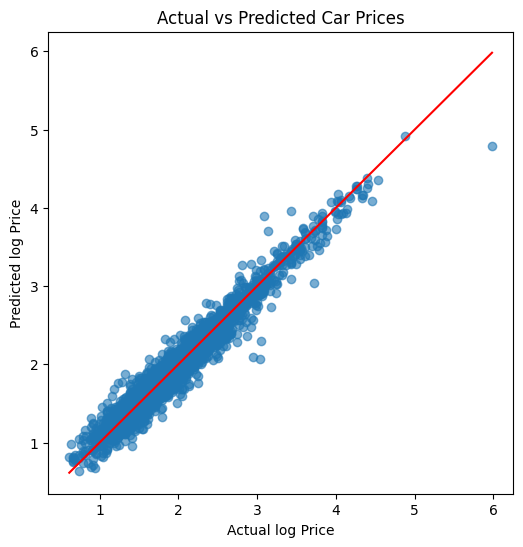

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual log Price")
plt.ylabel("Predicted log Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()

In [ ]:
# save the final model + the encoder ( need both for the Streamlit app later)
joblib.dump(best_xgb, "model.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(list(X_train.columns), "feature_columns.pkl")
print("Saved model.pkl, encoder.pkl, feature_columns.pkl")

Saved model.pkl, encoder.pkl, feature_columns.pkl


In [29]:
categorical_options = {col: sorted(cleaned_car_df[col].unique().tolist()) for col in categorical_columns}
joblib.dump(categorical_options, "categorical_options.pkl")
print(categorical_options.keys())

dict_keys(['car_name', 'brand', 'seller_type', 'fuel_type', 'transmission_type', 'seats'])


In [1]:
import joblib
cols = joblib.load("feature_columns.pkl")
print(cols)

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'km_driven_per_year', 'power_to_engine_ratio', 'car_name_Audi A4', 'car_name_Audi A6', 'car_name_Audi A8', 'car_name_Audi Q7', 'car_name_BMW 3', 'car_name_BMW 5', 'car_name_BMW 6', 'car_name_BMW 7', 'car_name_BMW X1', 'car_name_BMW X3', 'car_name_BMW X4', 'car_name_BMW X5', 'car_name_BMW Z4', 'car_name_Bentley Continental', 'car_name_Datsun GO', 'car_name_Datsun RediGO', 'car_name_Datsun redi-GO', 'car_name_Ferrari GTC4Lusso', 'car_name_Force Gurkha', 'car_name_Ford Aspire', 'car_name_Ford Ecosport', 'car_name_Ford Endeavour', 'car_name_Ford Figo', 'car_name_Ford Freestyle', 'car_name_Honda Amaze', 'car_name_Honda CR', 'car_name_Honda CR-V', 'car_name_Honda City', 'car_name_Honda Civic', 'car_name_Honda Jazz', 'car_name_Honda WR-V', 'car_name_Hyundai Aura', 'car_name_Hyundai Creta', 'car_name_Hyundai Elantra', 'car_name_Hyundai Grand', 'car_name_Hyundai Santro', 'car_name_Hyundai Tucson', 'car_name_Hyundai Venue', 'car_name

In [2]:
import joblib
enc = joblib.load("encoder.pkl")
print(enc)
print(enc.get_feature_names_out())

OneHotEncoder(handle_unknown='ignore', sparse_output=False)
['car_name_Audi A4' 'car_name_Audi A6' 'car_name_Audi A8'
 'car_name_Audi Q7' 'car_name_BMW 3' 'car_name_BMW 5' 'car_name_BMW 6'
 'car_name_BMW 7' 'car_name_BMW X1' 'car_name_BMW X3' 'car_name_BMW X4'
 'car_name_BMW X5' 'car_name_BMW Z4' 'car_name_Bentley Continental'
 'car_name_Datsun GO' 'car_name_Datsun RediGO' 'car_name_Datsun redi-GO'
 'car_name_Ferrari GTC4Lusso' 'car_name_Force Gurkha'
 'car_name_Ford Aspire' 'car_name_Ford Ecosport' 'car_name_Ford Endeavour'
 'car_name_Ford Figo' 'car_name_Ford Freestyle' 'car_name_Honda Amaze'
 'car_name_Honda CR' 'car_name_Honda CR-V' 'car_name_Honda City'
 'car_name_Honda Civic' 'car_name_Honda Jazz' 'car_name_Honda WR-V'
 'car_name_Hyundai Aura' 'car_name_Hyundai Creta'
 'car_name_Hyundai Elantra' 'car_name_Hyundai Grand'
 'car_name_Hyundai Santro' 'car_name_Hyundai Tucson'
 'car_name_Hyundai Venue' 'car_name_Hyundai Verna' 'car_name_Hyundai i10'
 'car_name_Hyundai i20' 'car_name_I

In [3]:
import joblib
m = joblib.load("model.pkl")
print(m)
print(type(m))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)
<class 'xgboost.sklearn.XGBRegressor'>
